# Corpus Exploration
Inspect the preprocessed passage corpus — passage counts, token distributions, source coverage, and top keywords per city.

Run this after `main.py --skip-collection` to verify preprocessing output.

In [1]:
import json
import os
import yaml
from pathlib import Path
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.figsize'] = (12, 5)
matplotlib.rcParams['axes.spines.top'] = False
matplotlib.rcParams['axes.spines.right'] = False

In [2]:
# load config
with open('../configs/config.yaml', 'r') as f:
    config = yaml.safe_load(f)

CITIES = config['cities']
PROCESSED_DIR = Path('..') / config['paths']['processed_data']
print(f'Cities: {len(CITIES)}')
print(f'Processed dir: {PROCESSED_DIR}')

Cities: 20
Processed dir: ..\data\processed


In [3]:
# load all passage files
corpus = {}
for city in CITIES:
    slug = city.lower().replace(' ', '_')
    path = PROCESSED_DIR / f'{slug}_passages.json'
    if path.exists():
        with open(path, 'r', encoding='utf-8') as f:
            corpus[city] = json.load(f)
    else:
        print(f'Missing: {path}')

print(f'Loaded {len(corpus)} cities')

Loaded 20 cities


## 1. Passage counts per city

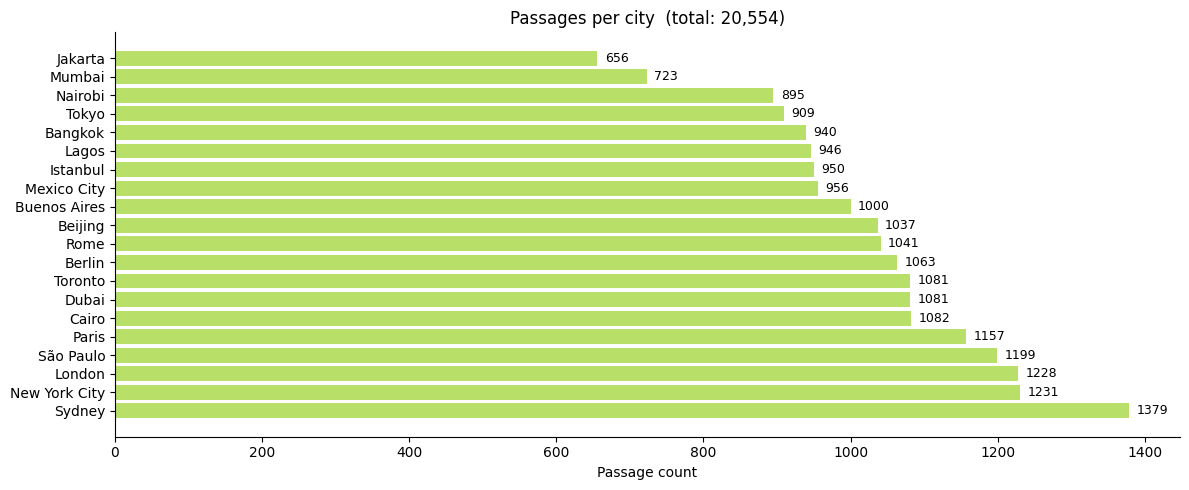

In [4]:
passage_counts = {city: corpus[city]['passage_count'] for city in corpus}
total = sum(passage_counts.values())

cities_sorted = sorted(passage_counts, key=passage_counts.get, reverse=True)
counts_sorted = [passage_counts[c] for c in cities_sorted]

fig, ax = plt.subplots()
bars = ax.barh(cities_sorted, counts_sorted, color='#b8e068', edgecolor='none')
ax.set_xlabel('Passage count')
ax.set_title(f'Passages per city  (total: {total:,})')
for bar, count in zip(bars, counts_sorted):
    ax.text(count + 10, bar.get_y() + bar.get_height()/2,
            str(count), va='center', fontsize=9)
plt.tight_layout()
plt.show()

## 2. Source breakdown per city

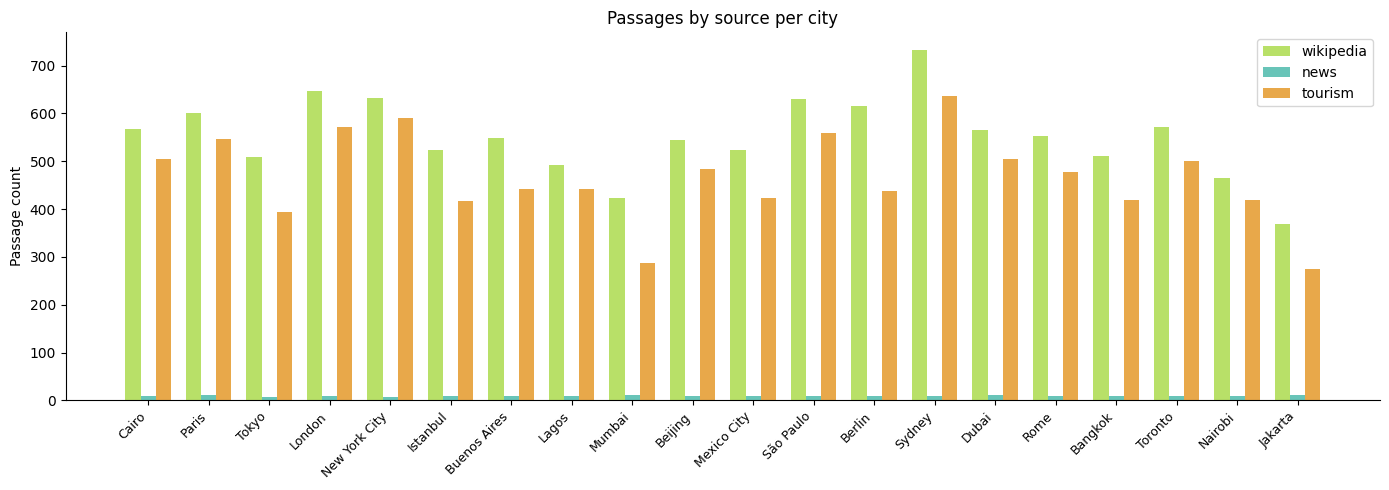

In [5]:
source_counts = {city: Counter() for city in corpus}
for city, data in corpus.items():
    for p in data['passages']:
        source_counts[city][p.get('source', 'unknown')] += 1

sources = ['wikipedia', 'news', 'tourism']
colors  = ['#b8e068', '#68c4b8', '#e8a84a']

x = range(len(corpus))
city_names = list(corpus.keys())
width = 0.25

fig, ax = plt.subplots(figsize=(14, 5))
for i, (src, col) in enumerate(zip(sources, colors)):
    vals = [source_counts[c][src] for c in city_names]
    ax.bar([xi + i*width for xi in x], vals, width, label=src, color=col, edgecolor='none')

ax.set_xticks([xi + width for xi in x])
ax.set_xticklabels(city_names, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Passage count')
ax.set_title('Passages by source per city')
ax.legend()
plt.tight_layout()
plt.show()

## 3. Token length distribution

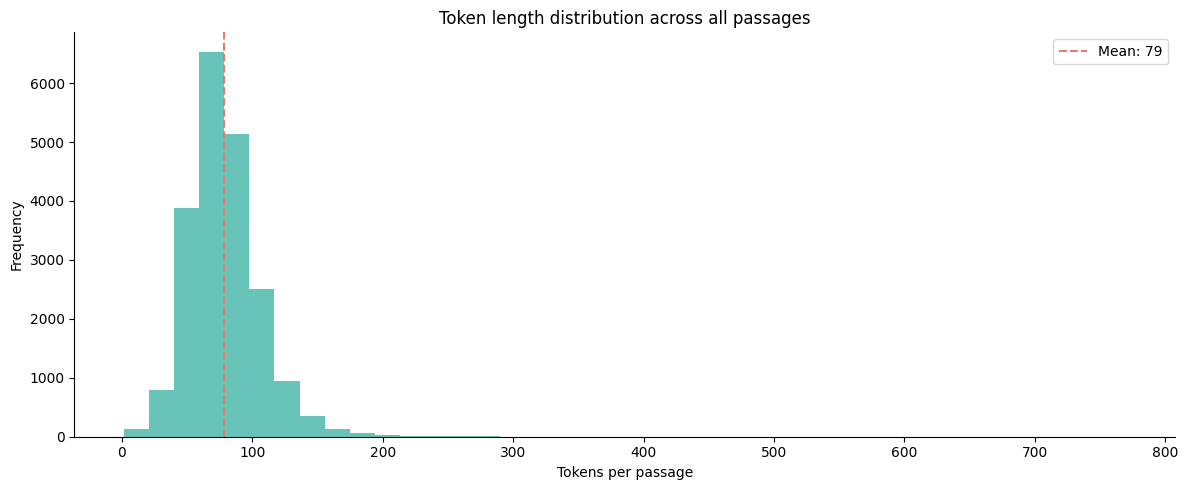

Min tokens : 2
Max tokens : 769
Mean tokens: 78.7


In [6]:
all_token_counts = []
for city, data in corpus.items():
    for p in data['passages']:
        all_token_counts.append(p.get('token_count', 0))

fig, ax = plt.subplots()
ax.hist(all_token_counts, bins=40, color='#68c4b8', edgecolor='none')
ax.axvline(sum(all_token_counts)/len(all_token_counts),
           color='#e87a6a', linestyle='--', label=f'Mean: {sum(all_token_counts)/len(all_token_counts):.0f}')
ax.set_xlabel('Tokens per passage')
ax.set_ylabel('Frequency')
ax.set_title('Token length distribution across all passages')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Min tokens : {min(all_token_counts)}')
print(f'Max tokens : {max(all_token_counts)}')
print(f'Mean tokens: {sum(all_token_counts)/len(all_token_counts):.1f}')

## 4. Top keywords per city (normalized tokens)

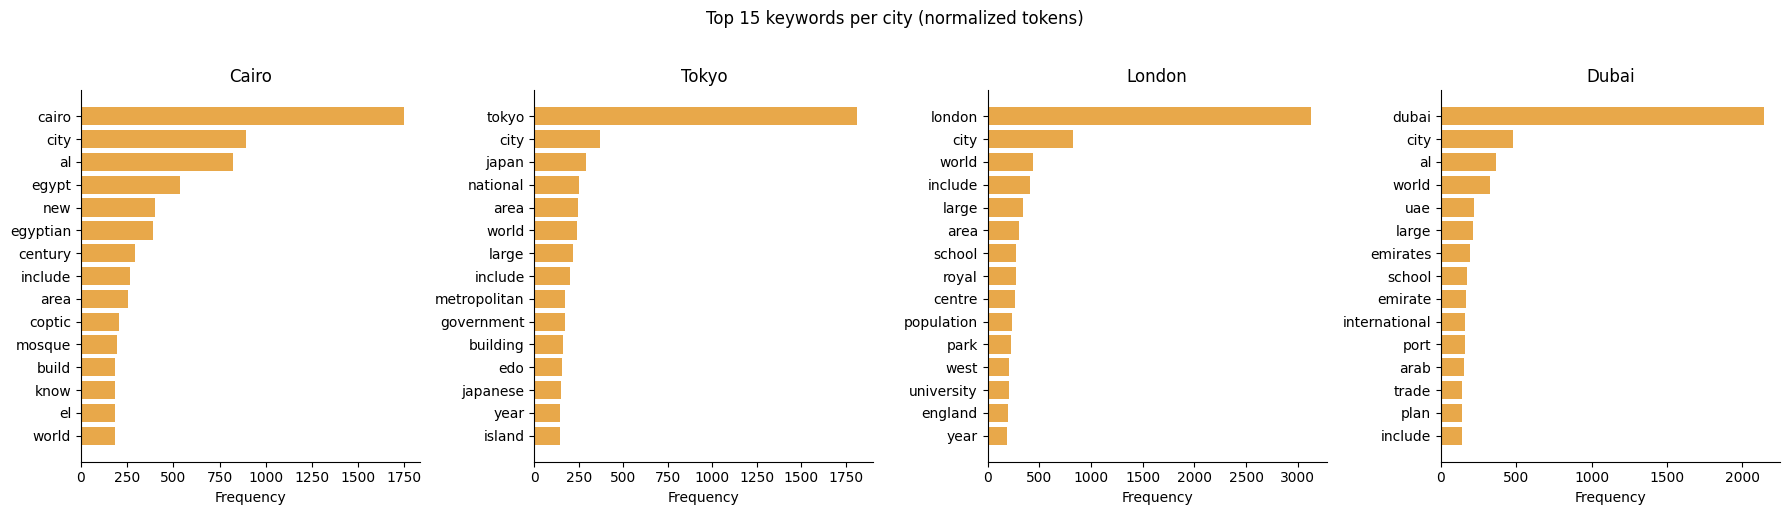

In [7]:
def top_keywords(city_data, n=15):
    counter = Counter()
    for p in city_data['passages']:
        counter.update(p.get('normalized_tokens', []))
    return counter.most_common(n)

# show top keywords for 4 sample cities
sample_cities = ['Cairo', 'Tokyo', 'London', 'Dubai']
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for ax, city in zip(axes, sample_cities):
    if city not in corpus:
        continue
    kws = top_keywords(corpus[city])
    words  = [k for k, _ in kws]
    counts = [v for _, v in kws]
    ax.barh(words[::-1], counts[::-1], color='#e8a84a', edgecolor='none')
    ax.set_title(city)
    ax.set_xlabel('Frequency')

plt.suptitle('Top 15 keywords per city (normalized tokens)', y=1.02)
plt.tight_layout()
plt.show()

## 5. Corpus summary table

In [8]:
print(f'{"City":<20} {"Passages":>10} {"Wiki":>8} {"News":>8} {"Tourism":>10} {"Avg tokens":>12}')
print('-' * 72)

for city in CITIES:
    if city not in corpus:
        continue
    data  = corpus[city]
    sc    = source_counts[city]
    tokens = [p.get('token_count', 0) for p in data['passages']]
    avg_t  = sum(tokens) / len(tokens) if tokens else 0
    print(f'{city:<20} {data["passage_count"]:>10} {sc["wikipedia"]:>8} {sc["news"]:>8} {sc["tourism"]:>10} {avg_t:>12.1f}')

print('-' * 72)
print(f'{"TOTAL":<20} {total:>10}')

City                   Passages     Wiki     News    Tourism   Avg tokens
------------------------------------------------------------------------
Cairo                      1082      568       10        504         86.5
Paris                      1157      600       11        546         83.0
Tokyo                       909      508        8        393         78.6
London                     1228      646       10        572         83.0
New York City              1231      633        8        590         82.4
Istanbul                    950      523       10        417         84.8
Buenos Aires               1000      549        9        442         84.3
Lagos                       946      493       10        443         68.5
Mumbai                      723      423       12        288         72.0
Beijing                    1037      544       10        483         83.5
Mexico City                 956      523       10        423         82.6
São Paulo                  1199      63